In [ ]:
import sys
sys.path.append("/Users/shikim/pynta_local/pynta/pynta")

# Preprocessing notebook

## Preprocessing notebook will calculate: 
1. notes for choice of pseudopotentials
2. Lattice parameter optimization and analysis
3. High surface index custom slab build
4. Energy convergence test
5. k-points optimization


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json

from ase.io import read
from ase.constraints import FixAtoms
from ase.visualize import view
from ase.build import surface

from pynta.calculator import get_lattice_parameters
from pynta.utils import name_to_ase_software

from pynta.preprocessing import *


### Notes on Pseudopotentials:

We can choose from various pseudopotential libraries. Choice of pseudopotential depends on the problem we are investigating, *e.g.,* if there is a heavy element present in our system and we are interested in the spin-orbit coupling effects, we should choose a full relativistic pseudopotential. We need to be careful whether our chosen pseudopotential correctly reproduces physical properties. Various pseudopotential libraries:

- https://www.quantum-espresso.org/pseudopotentials
- https://www.materialscloud.org/discover/sssp/table/efficiency
- http://www.pseudo-dojo.org
- https://www.physics.rutgers.edu/gbrv/
- https://nninc.cnf.cornell.edu
- http://www.quantum-simulation.org/potentials/
- BLYP pseudopotentials (https://pseudopotentials.quantum-espresso.org/legacy_tables/hartwigesen-goedecker-hutter-pp) 
- SCAN pseudopotentials (https://yaoyi92.github.io/scan-tm-pseudopotentials.html)


In [ ]:
#calculator
prep = Prep(
    metal="Pd",
    surface_type="fcc111",
    a0=3.89,
    software="Espresso",
    fmax=0.05,
    vacuum=10,
    software_kwargs={ # this keyword is to run convergence test
        "kpts": (3, 3, 1),
        "ecutwfc": 40,
        "ecutrho": 160,
        "occupations": "smearing",
        "smearing": "marzari-vanderbilt",
        "degauss": 0.01,
        "input_dft":"BEEF-VDW"
        "nosym": True,
        "conv_thr": 1e-6,
        "pseudopotentials": {
            "Pd": "pd_pbesol_v1.4.uspp.F.UPF",
            "H": "H.pbe-kjpaw_psl.1.0.0.UPF",
        },
    },
    lattice_opt_software_kwargs={ # this keyword is specifically for lattice constant optimization
            'kpts': (25,25,25), # something large
            'ecutwfc': 70,  # you can change this 
            'degauss':0.02,
            'input_dft':'BEEF-VDW', 
            'mixing_mode': 'plain'}, 
)

### 1. Lattice parameter optimization:


If your slab is not optimized, it is NOT recommended to use for Pynta production run. Please optimize your slab before running Pynta

*Preprocessing can only run with surfaces that ASE can build*

In [ ]:
# Analyze the lattice constant optimization output. Read the log file.
data = np.loadtxt(
    "lattice_constant_convergence.out",
    comments="#"
)

outavals = data[:, 0]
Evals = data[:, 1]


In [ ]:
# outavals, Evals already obtained via calculate_lattice_parameters() 
# Visualize the optimization results in a plot
a_interp, a_final = fit_lattice_constant_from_scan(
    outavals,
    Evals,
    title="Lattice constant optimization (bulk)",
)

### 2. Visualize (custom) surface:

In [ ]:
# Option 1 Conventional slab: 
# You ran prep.generate_slab(a=a0). You can visualize optimized slab here
view('slab.xyz', viewer='x3d')

In [ ]:
# Option 2: 
# You want to create custom slab. Generate slab here and visualize first see if this is structure you want.
name = 'pd332.xyz'
n_layers = 10
slab = surface('Pd',(3,3,2),n_layers)
slab.center(vacuum=10, axis=2)

#visualize your custom slab
write(name, slab)
view(slab, viewer='x3d')

In [ ]:
# Optimize custom slab

view('custom_slab.xyz', viewer='x3d')


### 3. Cutoff Energy convergence test: 

We can calculate the total energy of the system for various values of energy cutoff values. 
Converged energy cutoff value with peudopotentials of choice can construct more accurate DFT input for Pynta. 

In [ ]:
data = np.loadtxt("ecut_results.out", comments="#", dtype=str)

ecut_vals = data[:, 0].astype(float)
E_ads = data[:, 2].astype(float)


In [ ]:
plt.plot(ecut_vals, E_ads, marker="o")
plt.xlabel("Kinetic energy cutoff (Ry)")
plt.ylabel("Adsorption energy (eV)")
plt.title("ecutwfc convergence of adsorption energy")
plt.grid(True)
plt.show()

### 4. k-point convergence test:

With the optimized slab, appropriate k-points should be calculated to execute Pynta efficiently. 

Lowest total energy is estimated from lattice parameter optimization. We use the lowest potential energy to estimate k-points.

Tip: If you have already obtained satisfactory convergence with a (relatively) sparse k-point grid, there is no motivation to go for a denser grid. It makes calculations more expensive. 

In [ ]:
data = np.loadtxt("kpts_results.out", comments="#", dtype=str)

kpts = [tuple(map(int, k.strip("()").split(","))) for k in data[:, 1]]
kpts_x = [k[0] * k[1] for k in kpts]
E_ads = data[:, 2].astype(float)

In [ ]:
plt.plot(kpts_x, E_ads, marker="o")
plt.xlabel("k-point (kx × ky)")
plt.ylabel("Adsorption energy (eV)")
plt.grid(True)
plt.show()

## results

Optimized a: 3.9627826414963048


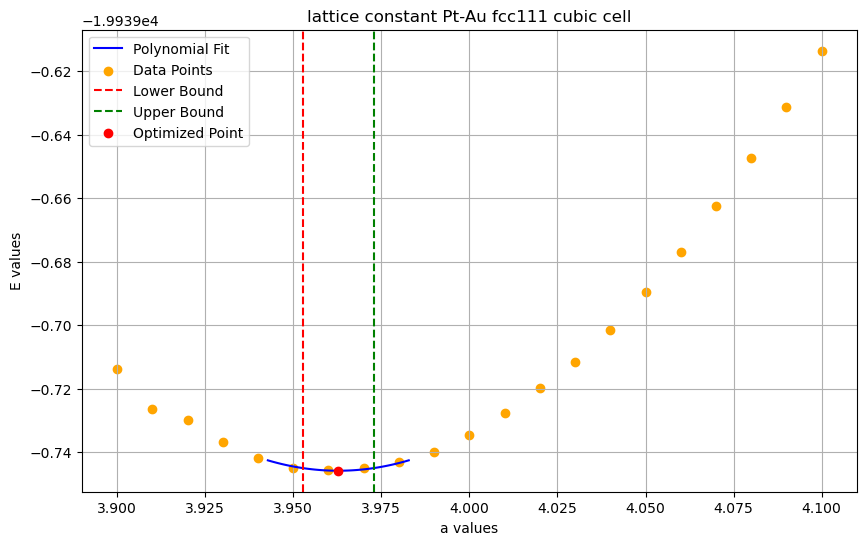

In [2]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Define the outavals and Evals
# Define the outavals and Evals
#outavals = [3.70, 3.71, 3.72, 3.73, 3.74, 3.75, 3.76, 3.77, 3.78, 3.79, 3.80, 3.81, 3.82, 3.83, 3.84, 3.85, 3.86, 3.87, 3.88, 3.89, 3.90]
#Evals = [-5907.5, -5907.4, -5907.3, -5907.2, -5907.1, -5907.0, -5906.9, -5906.8, -5906.7, -5906.6, -5906.5, -5906.4, -5906.3, -5906.2, -5906.1, -5906.0, -5905.9, -5905.8, -5905.7, -5905.6, -5905.5]
outavals = [3.8999999999999826, 3.9099999999999824, 3.919999999999982, 3.929999999999982, 3.9399999999999817, 3.9499999999999815, 3.9599999999999813, 3.969999999999981, 3.979999999999981, 3.9899999999999807, 3.9999999999999805, 4.00999999999998, 4.01999999999998, 4.02999999999998, 4.03999999999998, 4.049999999999979, 4.059999999999979, 4.069999999999979, 4.079999999999979, 4.0899999999999785, 4.099999999999978]
Evals = -19939.713847522256, -19939.72634122099, -19939.72981788345, -19939.736823454223, -19939.741878921173, -19939.74490795637, -19939.74573110073, -19939.745155171793, -19939.743282620413, -19939.740054806058, -19939.734668312623, -19939.727848187427, -19939.719920150736, -19939.711693605168, -19939.70153124175, -19939.689664221187, -19939.67688942886, -19939.66241855098, -19939.647523447624, -19939.631458526874, -19939.61359751873
# Step 1: Find the indices of the 7 smallest Evals
inds = np.argsort(Evals)[:7]

# Step 2: Fit a polynomial of degree 2 to the selected points
p = np.polyfit(np.array(outavals)[inds], np.array(Evals)[inds], 2)

# Step 3: Calculate the interpolated value of a
a = -p[1] / (2.0 * p[0])

# Step 4: Define the function to minimize
def f(x):
    # Evaluate the polynomial at x
    return np.polyval(p, x)

# Step 5: Set optimization options
options = {'xatol': 1e-4}

# Step 6: Minimize the function within the bounds
out = opt.minimize_scalar(f, method='bounded', bounds=(a - 0.01, a + 0.01), options=options)

# Step 7: Print the results
print("Optimized a: {}".format(out.x))

# Step 8: Plotting
# Create a range of x values for plotting the polynomial
x_values = np.linspace(a - 0.02, a + 0.02, 100)
y_values = f(x_values)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the polynomial
plt.plot(x_values, y_values, label='Polynomial Fit', color='blue')

# Plot the original data points
plt.scatter(outavals, Evals, color='orange', label='Data Points')

# Highlight the bounds used for optimization
plt.axvline(x=a - 0.01, color='red', linestyle='--', label='Lower Bound')
plt.axvline(x=a + 0.01, color='green', linestyle='--', label='Upper Bound')

# Highlight the optimized point
plt.scatter(out.x, f(out.x), color='red', label='Optimized Point', zorder=5)

# Add title and labels
plt.title('lattice constant Pt-Au fcc111 cubic cell')
plt.xlabel('a values')
plt.ylabel('E values')

# Show grid
plt.grid()

# Add a legend
plt.legend()

# Show the plot
plt.show()
